# Climate teleconnections and coastal temperature predictability

## Question and approach

**Can current-season climate indices help predict next-season coastal temperature anomalies, and is the signal different for the West Coast and East Coast?**

We compare broad West Coast and East Coast temperature anomalies using three climate indices: Niño 3.4, PDO, and AO. The setup is deliberately simple. We use the climate indices from one season to predict the temperature anomaly in the next season.

The goal is not to build the strongest possible forecast. We want to see whether a small linear-regression model carries useful one-season-ahead information, where it works better, and where it breaks down.


### Notebook setup

We start with the packages, then write a few small helper functions. After that, the notebook moves from temperature data to climate predictors, then to regression results.


In [1]:
from pathlib import Path

# Load the packages used for data, plots, and simple regression.
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Make plots clear when the notebook is opened.
plt.rcParams.update({"figure.dpi": 120})


### Helper functions

These helper functions are kept inside the notebook so the project can run from one file. They are grouped by task.


First, we read monthly data and turn it into seasons. This keeps the later cells focused on the analysis instead of file parsing.


In [2]:
# Common missing-value codes in the climate index files.
MISSING_VALUES = [99.99, -99.99, 999, -999, -9999]

# We use the same season order throughout the notebook.
SEASON_ORDER = ["DJF", "MAM", "JJA", "SON"]
SEASON_TO_NUMBER = {"DJF": 0, "MAM": 1, "JJA": 2, "SON": 3}
SEASON_START_MONTH = {"DJF": 12, "MAM": 3, "JJA": 6, "SON": 9}


def load_year_month_index(file_path, column_name, missing_values=MISSING_VALUES):
    """Read one year followed by 12 monthly values."""
    rows = []

    with Path(file_path).open("r") as data_file:
        for line in data_file:
            parts = line.split()

            # Data rows have one year and 12 monthly values.
            if len(parts) == 13 and parts[0].isdigit():
                year = int(parts[0])
                for month, value in enumerate(parts[1:], start=1):
                    rows.append(
                        {
                            "date": pd.Timestamp(year=year, month=month, day=1),
                            column_name: float(value),
                        }
                    )

    data = pd.DataFrame(rows).set_index("date").sort_index()

    # Use NaN so pandas can ignore missing values in averages.
    return data.replace(missing_values, np.nan)


def load_monthly_csv_index(file_path, column_name, missing_values=MISSING_VALUES):
    """Read a monthly index CSV with date and value columns."""
    data = pd.read_csv(
        file_path,
        names=["date", column_name],
        header=0,
        skipinitialspace=True,
    )
    data["date"] = pd.to_datetime(data["date"])
    data[column_name] = pd.to_numeric(data[column_name], errors="coerce")
    return data.set_index("date").sort_index().replace(missing_values, np.nan)


def add_season_columns(monthly_data):
    """Add season labels, with December assigned to the next DJF year."""
    data = monthly_data.copy()
    data["month"] = data.index.month
    data["season_year"] = data.index.year

    # December belongs to the following DJF season.
    data.loc[data["month"] == 12, "season_year"] += 1

    season_by_month = {
        12: "DJF",
        1: "DJF",
        2: "DJF",
        3: "MAM",
        4: "MAM",
        5: "MAM",
        6: "JJA",
        7: "JJA",
        8: "JJA",
        9: "SON",
        10: "SON",
        11: "SON",
    }
    data["season"] = data["month"].map(season_by_month)
    return data


def season_start_date(season_year, season):
    """Return the first month of a seasonal average."""
    if season == "DJF":
        return pd.Timestamp(year=int(season_year) - 1, month=12, day=1)
    return pd.Timestamp(year=int(season_year), month=SEASON_START_MONTH[season], day=1)


def make_seasonal_mean(monthly_data):
    """Convert monthly data into complete 3-month seasonal means."""
    data = add_season_columns(monthly_data)
    value_columns = [
        col for col in data.columns if col not in ["month", "season_year", "season"]
    ]

    grouped = data.groupby(["season_year", "season"])
    seasonal_mean = grouped[value_columns].mean()
    seasonal_count = grouped[value_columns].count()

    # Keep only seasons with all three months.
    complete_seasons = seasonal_count.eq(3).all(axis=1)
    seasonal_mean = seasonal_mean.loc[complete_seasons].reset_index()

    seasonal_mean["season"] = pd.Categorical(
        seasonal_mean["season"], SEASON_ORDER, ordered=True
    )
    seasonal_mean = seasonal_mean.sort_values(["season_year", "season"]).reset_index(drop=True)
    seasonal_mean["season"] = seasonal_mean["season"].astype(str)
    seasonal_mean["season_number"] = seasonal_mean["season"].map(SEASON_TO_NUMBER)
    seasonal_mean["season_id"] = seasonal_mean["season_year"] * 4 + seasonal_mean["season_number"]

    # These labels make later tables easier to read.
    seasonal_mean["date"] = [
        season_start_date(year, season)
        for year, season in zip(seasonal_mean["season_year"], seasonal_mean["season"])
    ]
    seasonal_mean["season_label"] = (
        seasonal_mean["season_year"].astype(str) + " " + seasonal_mean["season"]
    )

    return seasonal_mean


Next, we average each coastal box and keep the train/test split in time order. These two steps are used several times below.


In [3]:
def area_weighted_regional_mean(data_array, region_box):
    """Average a lat-lon box using cosine latitude weights."""

    # Select the grid cells inside the box.
    region = data_array.sel(
        lat=slice(region_box["lat_min"], region_box["lat_max"]),
        lon=slice(region_box["lon_min"], region_box["lon_max"]),
    )

    # Latitude weights make high-latitude cells count less.
    latitude_weights = np.cos(np.deg2rad(region.lat))
    return region.weighted(latitude_weights).mean(dim=["lat", "lon"])


def time_ordered_split(data, train_fraction=0.80):
    """Split rows in time order."""
    split_index = int(len(data) * train_fraction)
    return data.iloc[:split_index].copy(), data.iloc[split_index:].copy()


The last helper group evaluates the regressions. It returns the same metrics for every model, so the two coasts can be compared fairly.


In [4]:
def safe_correlation(observed, predicted):
    """Return NaN when correlation is not defined."""
    observed = np.asarray(observed)
    predicted = np.asarray(predicted)

    # Correlation is not useful for a constant series.
    if len(observed) < 2 or np.std(observed) <= 1e-12 or np.std(predicted) <= 1e-12:
        return np.nan

    return np.corrcoef(observed, predicted)[0, 1]


def calculate_metrics(observed, predicted):
    """Return the prediction metrics used below."""
    return {
        "RMSE": np.sqrt(mean_squared_error(observed, predicted)),
        "MAE": mean_absolute_error(observed, predicted),
        "R2": r2_score(observed, predicted),
        "test_correlation": safe_correlation(observed, predicted),
    }


def compute_vif(predictor_data):
    """Return simple variance inflation factors."""
    predictors = pd.DataFrame(predictor_data).copy()
    vif_rows = []

    for predictor_name in predictors.columns:
        other_names = [name for name in predictors.columns if name != predictor_name]

        if not other_names:
            vif_value = 1.0
        else:
            # Regress one predictor on the others.
            model = LinearRegression()
            model.fit(predictors[other_names], predictors[predictor_name])
            fitted_values = model.predict(predictors[other_names])
            r2 = r2_score(predictors[predictor_name], fitted_values)

            if r2 >= 1 - 1e-12:
                vif_value = np.inf
            else:
                vif_value = 1 / (1 - r2)

        vif_rows.append({"predictor": predictor_name, "VIF": vif_value})

    return pd.DataFrame(vif_rows)


def evaluate_models(data, target_column, region_name, model_specs, train_fraction=0.80):
    """Fit each model and return metrics plus full-model residuals."""
    train_data, test_data = time_ordered_split(data, train_fraction=train_fraction)
    y_train = train_data[target_column].values
    y_test = test_data[target_column].values

    result_rows = []
    full_model_predictions = None

    for model_name, predictor_columns in model_specs:
        if not predictor_columns:
            # The baseline predicts the training mean.
            predictions = np.repeat(y_train.mean(), len(test_data))
            coefficients = {}
        else:
            model = LinearRegression()
            model.fit(train_data[predictor_columns], y_train)
            predictions = model.predict(test_data[predictor_columns])
            coefficients = dict(zip(predictor_columns, model.coef_))

        result_row = {
            "region": region_name,
            "model": model_name,
            "nino34": coefficients.get("nino34", np.nan),
            "pdo": coefficients.get("pdo", np.nan),
            "ao": coefficients.get("ao", np.nan),
        }

        # Keep extra coefficients, such as the simple time trend.
        for predictor_name in predictor_columns:
            result_row[predictor_name] = coefficients.get(predictor_name, np.nan)

        result_row.update(calculate_metrics(y_test, predictions))
        result_rows.append(result_row)

        if model_name.lower() == "full":
            # Save full-model predictions for the residual plots.
            full_model_predictions = test_data[
                ["target_date", "target_season", "target_season_label", target_column]
            ].copy()
            full_model_predictions = full_model_predictions.rename(
                columns={target_column: "observed"}
            )
            full_model_predictions["predicted"] = predictions
            full_model_predictions["residual"] = (
                full_model_predictions["observed"] - full_model_predictions["predicted"]
            )
            full_model_predictions["region"] = region_name

    return pd.DataFrame(result_rows), full_model_predictions


def lag_one_autocorrelation(values):
    """Calculate lag-1 autocorrelation for residuals."""
    values = pd.Series(values).dropna()

    if len(values) < 3:
        return np.nan

    return values.autocorr(lag=1)


## Temperature targets

ERA5 gives monthly 2m temperature on a 1 x 1 degree grid. We first turn that gridded field into two regional time series: one for the West Coast and one for the East Coast.

The boxes are broad regional proxies. They are easy to reproduce, but they are not land-only masks. After the regional average, we remove the usual seasonal cycle so the target is a seasonal temperature anomaly.


In [5]:
# Load ERA5 temperature and convert Kelvin to Celsius.
era5_data = xr.open_dataset("data/ERA5_2mtemp_1x1.nc")
temperature_variable = list(era5_data.data_vars)[0]
temperature_c = era5_data[temperature_variable] - 273.15

# Check the variable name and date range before using it.
era5_summary = pd.DataFrame(
    {
        "item": ["variable", "first month", "last month"],
        "value": [
            temperature_variable,
            str(temperature_c.time.min().values)[:10],
            str(temperature_c.time.max().values)[:10],
        ],
    }
)
era5_summary


,item,value
0,variable,__xarray_dataarray_variable__
1,first month,1959-01-01
2,last month,2024-12-01


The ERA5 file gives us the full temperature record. Next we define the two coastal boxes that will become the prediction targets.


In [6]:
# Define broad boxes for the two coastal regions.
regions = {
    "West Coast": {"lat_min": 32, "lat_max": 49, "lon_min": 235, "lon_max": 244},
    "East Coast": {"lat_min": 25, "lat_max": 47, "lon_min": 279, "lon_max": 295},
}

# Convert longitudes from 0-360 to regular west/east labels for display.
region_table = pd.DataFrame(regions).T
region_table.index.name = "region"
region_table["lon_min_deg"] = region_table["lon_min"] - 360
region_table["lon_max_deg"] = region_table["lon_max"] - 360
region_table[["lat_min", "lat_max", "lon_min_deg", "lon_max_deg"]]


,lat_min,lat_max,lon_min_deg,lon_max_deg
region,,,,
West Coast,32,49,-125,-116
East Coast,25,47,-81,-65


The boxes below show the two target regions before we average the gridded data.


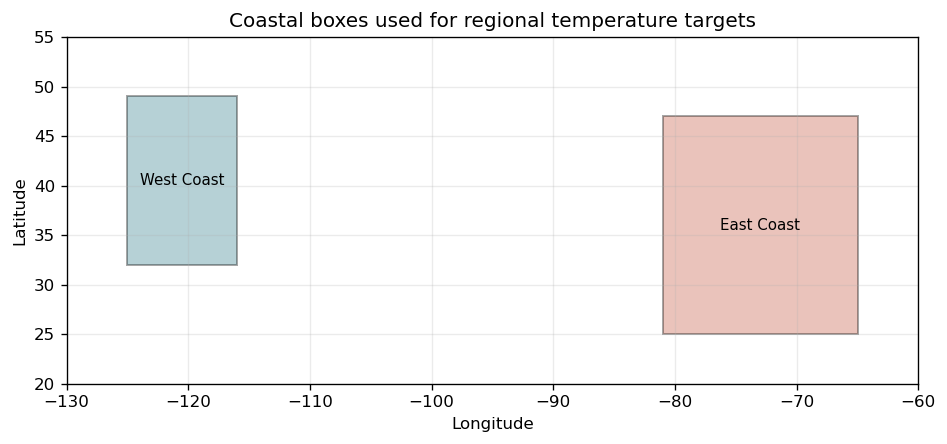

In [7]:
# Plot the boxes so the target regions are visible.
fig, ax = plt.subplots(figsize=(8, 3.8))
region_colors = {"West Coast": "#2F7C8C", "East Coast": "#C4553D"}

for region_name, row in region_table.iterrows():
    rect = Rectangle(
        (row["lon_min_deg"], row["lat_min"]),
        row["lon_max_deg"] - row["lon_min_deg"],
        row["lat_max"] - row["lat_min"],
        facecolor=region_colors[region_name],
        edgecolor="black",
        alpha=0.35,
        linewidth=1.2,
    )
    ax.add_patch(rect)
    ax.text(
        (row["lon_min_deg"] + row["lon_max_deg"]) / 2,
        (row["lat_min"] + row["lat_max"]) / 2,
        region_name,
        ha="center",
        va="center",
        fontsize=9,
    )

ax.set_xlim(-130, -60)
ax.set_ylim(20, 55)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Coastal boxes used for regional temperature targets")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()


After checking the boxes visually, we average all grid cells inside each box into one monthly temperature series.


In [8]:
# Build one monthly temperature series for each coast.
regional_temperature_monthly = pd.DataFrame(index=pd.to_datetime(temperature_c.time.values))

for region_name, region_box in regions.items():
    column_name = region_name.lower().replace(" ", "_") + "_temperature_c"
    regional_temperature_monthly[column_name] = area_weighted_regional_mean(
        temperature_c,
        region_box,
    ).to_series().values


Now we turn monthly temperatures into seasonal anomalies. This removes the usual winter-summer cycle before modeling.


In [9]:
# Convert monthly regional temperatures to seasonal means.
seasonal_temperature = make_seasonal_mean(regional_temperature_monthly)

for coast in ["west_coast", "east_coast"]:
    temperature_column = coast + "_temperature_c"
    anomaly_column = coast + "_temperature_anomaly_c"

    # Remove each coast's usual mean for that season.
    seasonal_temperature[anomaly_column] = (
        seasonal_temperature[temperature_column]
        - seasonal_temperature.groupby("season")[temperature_column].transform("mean")
    )

target_summary = pd.DataFrame(
    {
        "target": ["West Coast anomaly", "East Coast anomaly"],
        "first season": seasonal_temperature["season_label"].iloc[0],
        "last season": seasonal_temperature["season_label"].iloc[-1],
        "missing values": [
            seasonal_temperature["west_coast_temperature_anomaly_c"].isna().sum(),
            seasonal_temperature["east_coast_temperature_anomaly_c"].isna().sum(),
        ],
    }
)
target_summary


,target,first season,last season,missing values
0,West Coast anomaly,1959 MAM,2024 SON,0
1,East Coast anomaly,1959 MAM,2024 SON,0


The target summary checks that both anomaly series are complete. Then we plot the two targets to see the broad time pattern.


The anomaly time series is our first check. If the two coasts moved together every season, comparing them would not add much. They share some warm and cool periods, but they also separate often enough to make the regional comparison useful.


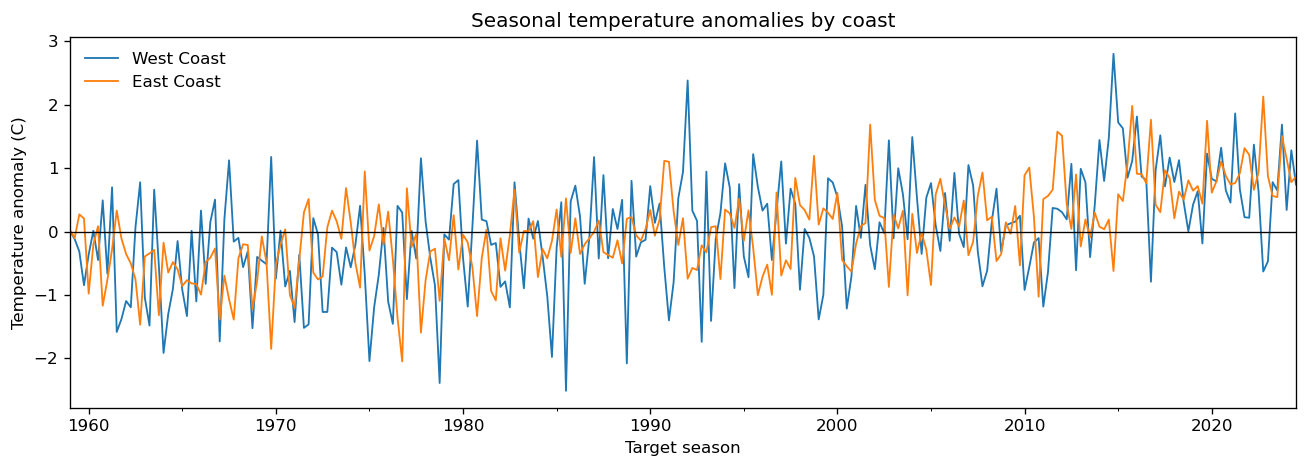

In [10]:
# Plot the two anomaly targets on the same axis.
anomaly_plot_data = seasonal_temperature.set_index("date")[[
    "west_coast_temperature_anomaly_c",
    "east_coast_temperature_anomaly_c",
]]

ax = anomaly_plot_data.plot(figsize=(11, 4), linewidth=1.1)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Seasonal temperature anomalies by coast")
ax.set_xlabel("Target season")
ax.set_ylabel("Temperature anomaly (C)")
ax.legend(["West Coast", "East Coast"], frameon=False)
plt.tight_layout()
plt.show()


The later part of the record has many positive anomalies. This matters for prediction because the models train mostly on earlier seasons and then have to predict a warmer held-out period using only three climate indices.


## Climate predictors

The predictor side is smaller. Niño 3.4 and PDO describe Pacific variability, while AO describes a broad Northern Hemisphere circulation pattern.

We average each monthly index into the same DJF, MAM, JJA, and SON seasons used for temperature. This keeps the timing consistent before we build the one-season-ahead table.


In [11]:
# Load the three monthly climate indices.
nino34_monthly = load_year_month_index("data/nina34.anom.data", "nino34")
pdo_monthly = load_year_month_index("data/ersst.v5.pdo.dat", "pdo")
ao_monthly = load_monthly_csv_index("data/ao.long.csv", "ao")

# Put the indices in one table before seasonal averaging.
climate_indices_monthly = pd.concat(
    [nino34_monthly, pdo_monthly, ao_monthly],
    axis=1,
    sort=True,
).dropna(how="all")

seasonal_climate_indices = make_seasonal_mean(climate_indices_monthly)


The climate indices now use the same seasonal calendar as the temperature targets. We check their basic ranges before merging them with the target table.


In [12]:
# Summarize the predictor columns before modeling.
predictor_summary = seasonal_climate_indices[["nino34", "pdo", "ao"]].agg(
    ["count", "mean", "std", "min", "max"]
).T
predictor_summary.round(2)


,count,mean,std,min,max
nino34,302.0,-0.17,0.85,-2.06,2.50
pdo,302.0,-0.48,1.09,-3.50,2.10
ao,302.0,-0.08,0.70,-3.42,2.69


The three predictors cover the period needed for the regression table. Their means are near zero, so the coefficients are easy to read as changes in temperature anomaly per one-unit change in each index.


## One-season-ahead dataset

This table carries the prediction question. Each row pairs climate indices from one season with temperature anomaly in the following season.

This lag is important. A same-season table would mostly describe co-movement after the fact. Here we ask whether the current season leaves any signal for the next one.


In [13]:
# Keep the current-season predictors.
predictor_table = seasonal_climate_indices[[
    "date", "season", "season_year", "season_id", "season_label", "nino34", "pdo", "ao",
]].copy()

predictor_table = predictor_table.rename(
    columns={
        "season_year": "predictor_season_year",
        "season_id": "predictor_season_id",
        "season_label": "predictor_season_label",
    }
)


Next we build the target table. The main trick is the one-season shift: each target season points back to the previous predictor season.


In [14]:
# Keep the next-season temperature targets.
target_table = seasonal_temperature[[
    "date",
    "season",
    "season_year",
    "season_id",
    "season_label",
    "west_coast_temperature_anomaly_c",
    "east_coast_temperature_anomaly_c",
]].copy()

# This makes each target join to the previous season's predictors.
target_table["predictor_season_id"] = target_table["season_id"] - 1


In [15]:
# Rename the target columns so the lag is clear.
target_table = target_table.rename(
    columns={
        "date": "target_date",
        "season": "target_season",
        "season_year": "target_season_year",
        "season_id": "target_season_id",
        "season_label": "target_season_label",
        "west_coast_temperature_anomaly_c": "west_temperature_anomaly_next_season",
        "east_coast_temperature_anomaly_c": "east_temperature_anomaly_next_season",
    }
)


In [16]:
# Merge predictors with the next-season targets.
modeling_data = predictor_table.merge(target_table, on="predictor_season_id", how="inner")

# Drop rows that are missing a predictor or target value.
modeling_data = modeling_data.dropna(
    subset=[
        "nino34",
        "pdo",
        "ao",
        "west_temperature_anomaly_next_season",
        "east_temperature_anomaly_next_season",
    ]
).sort_values("target_season_id").reset_index(drop=True)

modeling_columns = [
    "predictor_season_label",
    "target_season_label",
    "nino34",
    "pdo",
    "ao",
    "west_temperature_anomaly_next_season",
    "east_temperature_anomaly_next_season",
]


This merged table is the final modeling dataset. The summary below checks the time span and row count.


In [17]:
# Check the final modeling table.
modeling_summary = pd.DataFrame(
    {
        "item": ["first predictor season", "last predictor season", "rows", "columns"],
        "value": [
            modeling_data["predictor_season_label"].iloc[0],
            modeling_data["predictor_season_label"].iloc[-1],
            len(modeling_data),
            len(modeling_columns),
        ],
    }
)

modeling_summary


,item,value
0,first predictor season,1959 DJF
1,last predictor season,2024 JJA
2,rows,263
3,columns,7


In [18]:
modeling_data[modeling_columns].head()

,predictor_season_label,target_season_label,nino34,pdo,ao,west_temperature_anomaly_next_season,east_temperature_anomaly_next_season
0,1959 DJF,1959 MAM,0.326667,0.843333,-0.385333,0.008044,0.025009
1,1959 MAM,1959 JJA,0.006667,-0.143333,0.403333,-0.117059,-0.104381
2,1959 JJA,1959 SON,-0.660000,-0.166667,-0.224333,-0.315661,0.270713
3,1959 SON,1960 DJF,-0.646667,0.603333,-0.647000,-0.847931,0.204824
4,1960 DJF,1960 MAM,-0.386667,0.623333,-1.579333,-0.362092,-0.980215


The preview confirms the lagged structure: one predictor season is paired with the next target season.


## Correlation and collinearity

Before fitting regressions, we check two things from the regression lectures. First, we check how the predictors and targets relate to each other. Second, we check whether the predictors are strongly collinear.

Collinearity does not make a model useless, but it can make individual coefficients harder to interpret.


In [19]:
# Correlate predictors with both next-season targets.
correlation_columns = [
    "nino34",
    "pdo",
    "ao",
    "west_temperature_anomaly_next_season",
    "east_temperature_anomaly_next_season",
]
correlation_matrix = modeling_data[correlation_columns].corr()


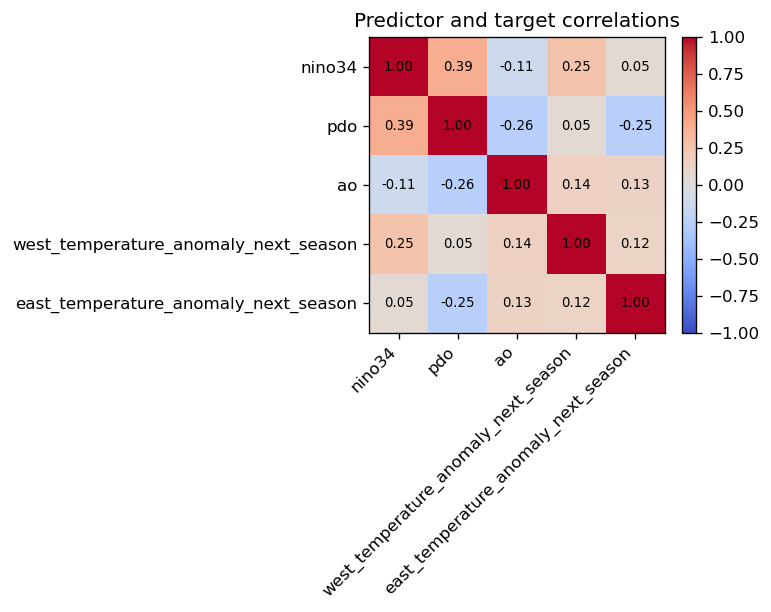

In [20]:
# Plot the correlation matrix as a heatmap.
fig, ax = plt.subplots(figsize=(6.6, 5.2))
image = ax.imshow(correlation_matrix, vmin=-1, vmax=1, cmap="coolwarm")

ax.set_xticks(range(len(correlation_columns)))
ax.set_yticks(range(len(correlation_columns)))
ax.set_xticklabels(correlation_columns, rotation=45, ha="right")
ax.set_yticklabels(correlation_columns)

for row in range(len(correlation_columns)):
    for col in range(len(correlation_columns)):
        ax.text(
            col,
            row,
            f"{correlation_matrix.iloc[row, col]:.2f}",
            ha="center",
            va="center",
            fontsize=8,
        )

ax.set_title("Predictor and target correlations")
fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()


Niño 3.4 and PDO have a moderate positive correlation, so their coefficients should be read together. The West Coast target has a clearer positive relationship with Niño 3.4 than the East Coast target does. The East Coast relationship is weaker and leans more toward PDO in this setup.


In [21]:
# Check whether the predictors are too collinear.
vif_table = compute_vif(modeling_data[["nino34", "pdo", "ao"]])
vif_table.round(2)


,predictor,VIF
0,nino34,1.18
1,pdo,1.25
2,ao,1.07


The VIF values are close to 1, so collinearity is not severe here. We should still interpret the coefficients as partial regression effects, especially for Niño 3.4 and PDO.


## Regression comparison and out-of-sample skill

Now we compare the same four models for each coast. The baseline uses the training-period mean and no climate information. The other models add Niño 3.4, then PDO, then AO.

We use a time-ordered 80/20 split. Earlier seasons train the models, and later seasons test them. A random split would mix time periods and make the prediction problem look easier than it is.


In [22]:
# Add predictors step by step so the models stay easy to compare.
model_specs = [
    ("Baseline", []),
    ("Niño-only", ["nino34"]),
    ("Niño + PDO", ["nino34", "pdo"]),
    ("Full", ["nino34", "pdo", "ao"]),
]


In [23]:
# Show the time-ordered split used inside the model function.
train_data, test_data = time_ordered_split(modeling_data)

split_summary = pd.DataFrame(
    {
        "set": ["Train", "Test"],
        "first target season": [
            train_data["target_season_label"].iloc[0],
            test_data["target_season_label"].iloc[0],
        ],
        "last target season": [
            train_data["target_season_label"].iloc[-1],
            test_data["target_season_label"].iloc[-1],
        ],
        "rows": [len(train_data), len(test_data)],
    }
)

split_summary


,set,first target season,last target season,rows
0,Train,1959 MAM,2011 JJA,210
1,Test,2011 SON,2024 SON,53


After the split check, we fit the same model list for each coast. This keeps the regional comparison fair.


In [24]:
# Fit the same models for both target regions.
west_model_results, west_full_predictions = evaluate_models(
    modeling_data,
    "west_temperature_anomaly_next_season",
    "West Coast",
    model_specs,
)

east_model_results, east_full_predictions = evaluate_models(
    modeling_data,
    "east_temperature_anomaly_next_season",
    "East Coast",
    model_specs,
)


In [25]:
# Combine model results into tables for reading and plotting.
model_results = pd.concat([west_model_results, east_model_results], ignore_index=True)
full_model_predictions = pd.concat(
    [west_full_predictions, east_full_predictions],
    ignore_index=True,
)

performance_table = model_results[["region", "model", "RMSE", "MAE", "R2", "test_correlation"]]
performance_table = performance_table.rename(columns={"R2": "R²"})
performance_table.round(3)


,region,model,RMSE,MAE,R²,test_correlation
0,West Coast,Baseline,1.174,1.025,-1.914,NaN
1,West Coast,Niño-only,1.117,0.971,-1.639,0.316
2,West Coast,Niño + PDO,1.134,0.992,-1.719,0.363
3,West Coast,Full,1.115,0.962,-1.629,0.363
4,East Coast,Baseline,1.089,0.964,-3.080,NaN
5,East Coast,Niño-only,1.093,0.968,-3.115,-0.077
6,East Coast,Niño + PDO,1.028,0.902,-2.636,0.253
7,East Coast,Full,1.026,0.900,-2.625,0.265


### Baseline skill check

Lecture 8 treats prediction as a held-out test problem. Here the baseline is the training-period mean, so this table asks a simple question: does a regression beat a forecast with no climate indices?



In [26]:
# Compare each model with the training-mean baseline in the same region.
baseline_rmse = (
    model_results[model_results["model"] == "Baseline"]
    .set_index("region")["RMSE"]
)

skill_table = model_results.copy()
skill_table["baseline_RMSE"] = skill_table["region"].map(baseline_rmse)
skill_table["RMSE_change_vs_baseline"] = skill_table["RMSE"] - skill_table["baseline_RMSE"]
skill_table["percent_change_vs_baseline"] = (
    100 * skill_table["RMSE_change_vs_baseline"] / skill_table["baseline_RMSE"]
)

skill_table_display = skill_table[
    [
        "region",
        "model",
        "RMSE",
        "baseline_RMSE",
        "RMSE_change_vs_baseline",
        "percent_change_vs_baseline",
        "R2",
        "test_correlation",
    ]
].rename(columns={"R2": "R²"})

skill_table_display.round(3)



,region,model,RMSE,baseline_RMSE,RMSE_change_vs_baseline,percent_change_vs_baseline,R²,test_correlation
0,West Coast,Baseline,1.174,1.174,0.000,0.000,-1.914,NaN
1,West Coast,Niño-only,1.117,1.174,-0.057,-4.825,-1.639,0.316
2,West Coast,Niño + PDO,1.134,1.174,-0.040,-3.400,-1.719,0.363
3,West Coast,Full,1.115,1.174,-0.059,-5.022,-1.629,0.363
4,East Coast,Baseline,1.089,1.089,0.000,0.000,-3.080,NaN
5,East Coast,Niño-only,1.093,1.089,0.005,0.425,-3.115,-0.077
6,East Coast,Niño + PDO,1.028,1.089,-0.061,-5.604,-2.636,0.253
7,East Coast,Full,1.026,1.089,-0.063,-5.750,-2.625,0.265


The regression models usually reduce RMSE a little compared with the training-mean baseline. The gains are small, and test R² is still negative because the test period is warmer than the training period.



### Trend sensitivity check

Lecture 9 and Lecture 10 both warn us to check whether a time series behaves the same way across the whole record. We add one simple trend term, measured in decades, to see whether the warm test period is part of the problem.



In [27]:
# A simple trend term keeps the check easy to explain.
modeling_data_with_trend = modeling_data.sort_values("target_date").reset_index(drop=True).copy()
modeling_data_with_trend["time_index"] = np.arange(len(modeling_data_with_trend))
modeling_data_with_trend["time_decade"] = modeling_data_with_trend["time_index"] / 40

trend_model_specs = [
    ("Baseline", []),
    ("Trend only", ["time_decade"]),
    ("Indices only", ["nino34", "pdo", "ao"]),
    ("Indices + trend", ["nino34", "pdo", "ao", "time_decade"]),
]

west_trend_results, _ = evaluate_models(
    modeling_data_with_trend,
    "west_temperature_anomaly_next_season",
    "West Coast",
    trend_model_specs,
)
east_trend_results, _ = evaluate_models(
    modeling_data_with_trend,
    "east_temperature_anomaly_next_season",
    "East Coast",
    trend_model_specs,
)

trend_results = pd.concat([west_trend_results, east_trend_results], ignore_index=True)

trend_table = trend_results[
    ["region", "model", "RMSE", "MAE", "R2", "test_correlation", "time_decade"]
].rename(columns={"R2": "R²", "time_decade": "trend_coef"})

trend_table.round(3)



,region,model,RMSE,MAE,R²,test_correlation,trend_coef
0,West Coast,Baseline,1.174,1.025,-1.914,NaN,NaN
1,West Coast,Trend only,0.831,0.669,-0.459,-0.037,0.150
2,West Coast,Indices only,1.115,0.962,-1.629,0.363,NaN
3,West Coast,Indices + trend,0.808,0.667,-0.381,0.375,0.135
4,East Coast,Baseline,1.089,0.964,-3.080,NaN,NaN
5,East Coast,Trend only,0.684,0.536,-0.610,0.339,0.153
6,East Coast,Indices only,1.026,0.900,-2.625,0.265,NaN
7,East Coast,Indices + trend,0.659,0.508,-0.494,0.275,0.154


The trend check is a sensitivity check. If the trend term helps, part of the error is connected to the later warm period as well as Nino 3.4, PDO, and AO.



In [28]:
# Keep the regression coefficients in a separate table.
coefficient_table = model_results[["region", "model", "nino34", "pdo", "ao"]]
coefficient_table.round(3)


,region,model,nino34,pdo,ao
0,West Coast,Baseline,NaN,NaN,NaN
1,West Coast,Niño-only,0.203,NaN,NaN
2,West Coast,Niño + PDO,0.184,0.037,NaN
3,West Coast,Full,0.188,0.076,0.174
4,East Coast,Baseline,NaN,NaN,NaN
5,East Coast,Niño-only,-0.020,NaN,NaN
6,East Coast,Niño + PDO,0.026,-0.090,NaN
7,East Coast,Full,0.026,-0.088,0.011


### Coefficient interpretation

The coefficient signs make the regional story easier to explain. We should read them as partial regression effects, not as causal proof.



In [29]:
# Show the full-model coefficient direction in a small table.
coefficient_interpretation = (
    coefficient_table[coefficient_table["model"] == "Full"]
    .melt(
        id_vars=["region", "model"],
        value_vars=["nino34", "pdo", "ao"],
        var_name="predictor",
        value_name="coefficient",
    )
)

coefficient_interpretation["direction"] = np.where(
    coefficient_interpretation["coefficient"] >= 0,
    "positive",
    "negative",
)
coefficient_interpretation["absolute_size"] = coefficient_interpretation["coefficient"].abs()
coefficient_interpretation = coefficient_interpretation.sort_values(
    ["region", "absolute_size"],
    ascending=[True, False],
)

coefficient_interpretation[
    ["region", "predictor", "coefficient", "direction"]
].round(3)



,region,predictor,coefficient,direction
3,East Coast,pdo,-0.088,negative
1,East Coast,nino34,0.026,positive
5,East Coast,ao,0.011,positive
0,West Coast,nino34,0.188,positive
4,West Coast,ao,0.174,positive
2,West Coast,pdo,0.076,positive


This table gives us plain language for the slides: which predictors move with warmer target-season coastal temperature after the other predictors are held fixed.



The tables give the numbers. The next two plots make the error and coefficient patterns easier to compare.


The performance table separates forecast skill from coefficient interpretation. RMSE and MAE measure error size. R² compares the predictions with the test-period mean. Test correlation checks whether the predictions move in the right direction.


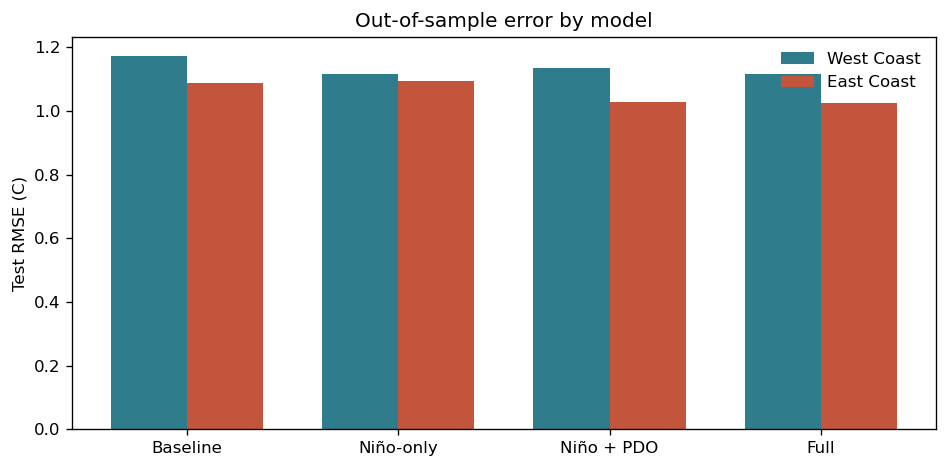

In [30]:
# Compare test RMSE across the four model setups.
plot_order = ["Baseline", "Niño-only", "Niño + PDO", "Full"]
rmse_plot_data = performance_table.pivot(index="model", columns="region", values="RMSE").loc[plot_order]

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(rmse_plot_data.index))
width = 0.36

ax.bar(x - width / 2, rmse_plot_data["West Coast"], width, label="West Coast", color="#2F7C8C")
ax.bar(x + width / 2, rmse_plot_data["East Coast"], width, label="East Coast", color="#C4553D")

ax.set_xticks(x)
ax.set_xticklabels(rmse_plot_data.index)
ax.set_ylabel("Test RMSE (C)")
ax.set_title("Out-of-sample error by model")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()


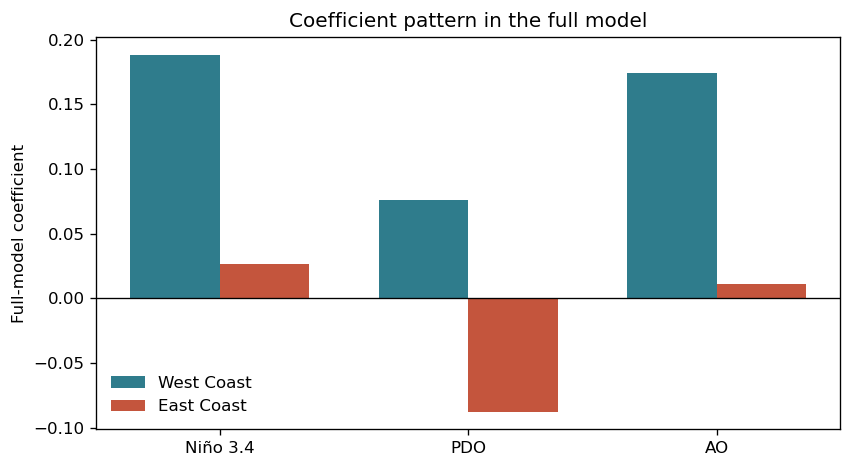

In [31]:
# Plot the full-model coefficients for the two coasts.
full_coefficients = coefficient_table[coefficient_table["model"] == "Full"]
full_coefficients = full_coefficients.set_index("region")[["nino34", "pdo", "ao"]]

fig, ax = plt.subplots(figsize=(7.2, 4))
x = np.arange(len(full_coefficients.columns))
width = 0.36

ax.bar(x - width / 2, full_coefficients.loc["West Coast"], width, label="West Coast", color="#2F7C8C")
ax.bar(x + width / 2, full_coefficients.loc["East Coast"], width, label="East Coast", color="#C4553D")

ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(["Niño 3.4", "PDO", "AO"])
ax.set_ylabel("Full-model coefficient")
ax.set_title("Coefficient pattern in the full model")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()


The full model modestly reduces RMSE compared with the training-mean baseline, but the held-out test skill is still weak. The negative test R² values tell us the model does not beat the test-period mean, which is a hard benchmark in a warmer test period.


## Residual diagnostics

Residuals show what the model misses. We define residual as observed anomaly minus predicted anomaly. Positive residuals mean the model predicted too cold.

This check matters because the test period is warmer than much of the training period. A model driven only by Niño 3.4, PDO, and AO may miss part of that background shift.


In [32]:
# Summarize full-model residuals for the test period.
residual_summary = (
    full_model_predictions
    .groupby("region")
    .agg(
        mean_residual=("residual", "mean"),
        residual_std=("residual", "std"),
        minimum_residual=("residual", "min"),
        maximum_residual=("residual", "max"),
        lag1_residual_correlation=("residual", lag_one_autocorrelation),
    )
    .reset_index()
)

residual_summary.round(3)


,region,mean_residual,residual_std,minimum_residual,maximum_residual,lag1_residual_correlation
0,East Coast,0.884,0.527,-0.319,2.178,0.283
1,West Coast,0.912,0.647,-0.534,2.832,0.059


### Seasonal residual check

Because the target is seasonal, we check whether errors change across DJF, MAM, JJA, and SON. This connects the residuals back to the seasonal setup.



In [33]:
# Summarize full-model residuals by target season.
season_residual_summary = (
    full_model_predictions.groupby(["region", "target_season"])
    .agg(
        mean_residual=("residual", "mean"),
        RMSE=("residual", lambda values: np.sqrt(np.mean(values ** 2))),
        MAE=("residual", lambda values: np.mean(np.abs(values))),
        count=("residual", "size"),
    )
    .reset_index()
)

season_residual_summary["target_season"] = pd.Categorical(
    season_residual_summary["target_season"],
    categories=SEASON_ORDER,
    ordered=True,
)
season_residual_summary = season_residual_summary.sort_values(["region", "target_season"])

season_residual_summary.round(3)



,region,target_season,mean_residual,RMSE,MAE,count
0,East Coast,DJF,1.279,1.457,1.328,13
2,East Coast,MAM,0.816,0.922,0.834,13
1,East Coast,JJA,0.697,0.739,0.697,13
3,East Coast,SON,0.753,0.849,0.753,14
4,West Coast,DJF,0.743,1.168,0.921,13
6,West Coast,MAM,0.897,1.034,0.897,13
5,West Coast,JJA,1.162,1.259,1.162,13
7,West Coast,SON,0.852,0.988,0.874,14


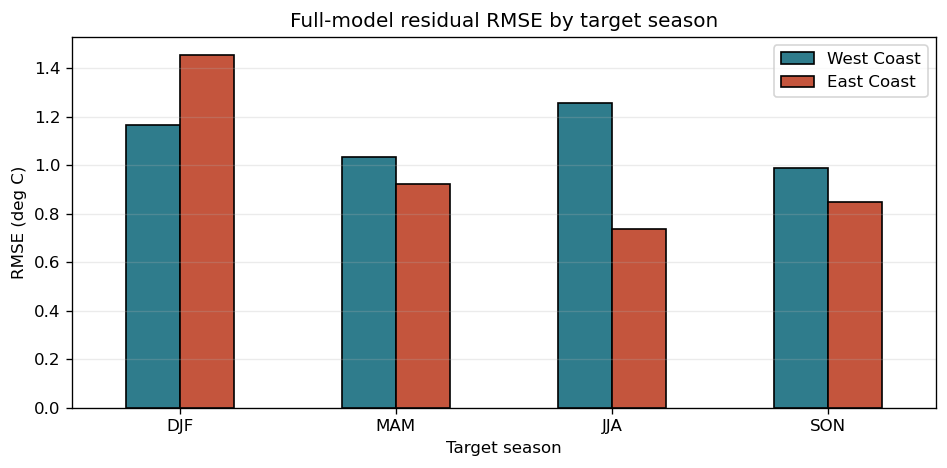

In [34]:
season_rmse = (
    season_residual_summary.pivot(
        index="target_season",
        columns="region",
        values="RMSE",
    )
    .loc[SEASON_ORDER, ["West Coast", "East Coast"]]
)

ax = season_rmse.plot(
    kind="bar",
    figsize=(8, 4),
    color=[region_colors["West Coast"], region_colors["East Coast"]],
    edgecolor="black",
)
ax.set_title("Full-model residual RMSE by target season")
ax.set_xlabel("Target season")
ax.set_ylabel("RMSE (deg C)")
ax.legend(title="")
ax.grid(axis="y", alpha=0.25)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()



Residual size changes by season, and every season still has visible error. That supports the same message as the time plots: the model has a real limitation across the test period.



The residual table gives the direction and spread of the errors. The plots below show whether the errors have a visible pattern.


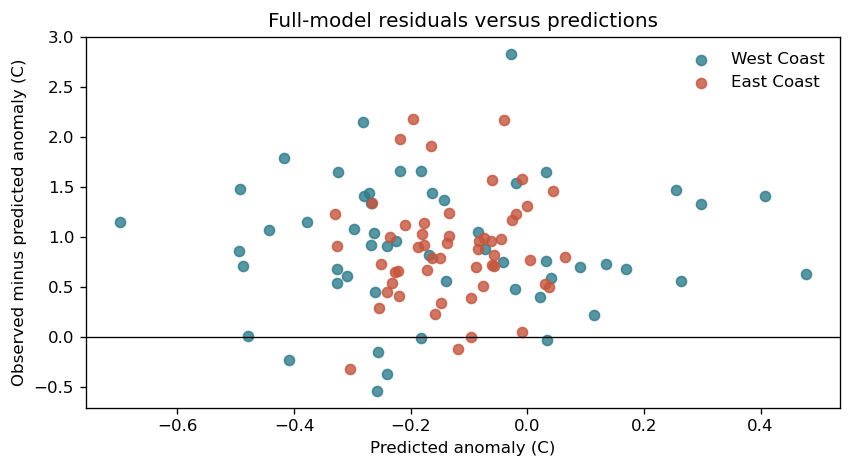

In [35]:
# Plot residuals against predicted values.
fig, ax = plt.subplots(figsize=(7.2, 4))

for region_name, color in region_colors.items():
    region_predictions = full_model_predictions[full_model_predictions["region"] == region_name]
    ax.scatter(
        region_predictions["predicted"],
        region_predictions["residual"],
        label=region_name,
        color=color,
        alpha=0.8,
    )

ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Full-model residuals versus predictions")
ax.set_xlabel("Predicted anomaly (C)")
ax.set_ylabel("Observed minus predicted anomaly (C)")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()


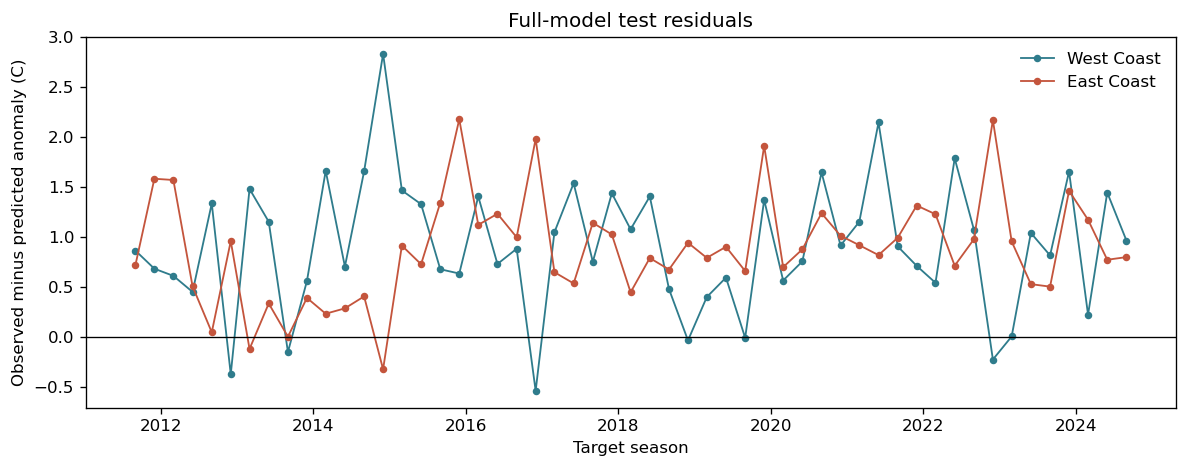

In [36]:
# Plot residuals through the held-out test period.
fig, ax = plt.subplots(figsize=(10, 4))

for region_name, color in region_colors.items():
    region_predictions = full_model_predictions[full_model_predictions["region"] == region_name]
    ax.plot(
        region_predictions["target_date"],
        region_predictions["residual"],
        marker="o",
        linewidth=1.1,
        markersize=3.5,
        label=region_name,
        color=color,
    )

ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Full-model test residuals")
ax.set_xlabel("Target season")
ax.set_ylabel("Observed minus predicted anomaly (C)")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()


The mean residual is positive for both coasts. Since residual is observed minus predicted, the full model tends to underpredict warm anomalies in the test period.

This is consistent with background warming or other nonstationary behavior that is not captured by the three climate indices. It is not a causal claim about warming. It simply says the simple teleconnection model misses part of the warmer later-period behavior.
